# Task 6: 开放探索 (Open-ended Exploration)

**Student Dropout and Academic Success Dataset**

本 Notebook 涵盖以下内容 / This notebook covers:
1. 集成学习模型 / Ensemble learning models (Random Forest, XGBoost/LightGBM)
2. 超参数调优 / Hyperparameter tuning (GridSearchCV)
3. 特征重要性分析 / Feature importance analysis
4. 学习曲线对比 / Learning curve comparison
5. 全模型综合对比 / Comprehensive comparison of all models

In [1]:
import sys
import os

# 添加项目根目录到路径 / Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, f1_score

from src.prediction import train_model, get_model
from src.evaluation import (
    calculate_metrics,
    plot_roc_curves,
    cross_validate_model,
    plot_learning_curve,
    metrics_comparison_table,
)

# 设置绘图风格 / Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

PLOT_DIR = os.path.join(project_root, "data", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

In [2]:
# 加载数据 / Load data
data_dir = os.path.join(project_root, "data")

X_train = pd.read_csv(os.path.join(data_dir, "features_engineered_train.csv"))
y_train = pd.read_csv(os.path.join(data_dir, "targets_engineered_train.csv")).iloc[:, 0]
X_val = pd.read_csv(os.path.join(data_dir, "features_engineered_val.csv"))
y_val = pd.read_csv(os.path.join(data_dir, "targets_engineered_val.csv")).iloc[:, 0]
X_test = pd.read_csv(os.path.join(data_dir, "features_engineered_test.csv"))
y_test = pd.read_csv(os.path.join(data_dir, "targets_engineered_test.csv")).iloc[:, 0]

X_trainval = pd.concat([X_train, X_val], ignore_index=True)
y_trainval = pd.concat([y_train, y_val], ignore_index=True)

print(f"Train+Val: {X_trainval.shape}, Test: {X_test.shape}")

Train+Val: (3539, 50), Test: (885, 50)


## 1. 集成学习 — Random Forest (Ensemble Learning — Random Forest)

Random Forest 是 bagging 方法的代表，通过构建多棵决策树并取多数投票来提升预测稳定性和准确率。
Random Forest is a bagging method that builds multiple decision trees and uses majority voting to improve stability and accuracy.

In [3]:
# 训练 Random Forest (默认参数) / Train Random Forest (default params)
rf_default = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_default.fit(X_train.values, y_train.values)

y_pred_rf = rf_default.predict(X_test.values)
metrics_rf = calculate_metrics(y_test.values, y_pred_rf)
print("Random Forest (default) — 测试集指标 / Test Metrics:")
for k, v in metrics_rf.items():
    print(f"  {k}: {v:.4f}")
print(f"\n分类报告 / Classification Report:")
print(classification_report(y_test.values, y_pred_rf, target_names=["Dropout", "Enrolled", "Graduate"]))

Random Forest (default) — 测试集指标 / Test Metrics:
  accuracy: 0.7751
  precision_macro: 0.7253
  precision_weighted: 0.7637
  recall_macro: 0.6997
  recall_weighted: 0.7751
  f1_macro: 0.7082
  f1_weighted: 0.7664

分类报告 / Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.76      0.78       284
    Enrolled       0.57      0.43      0.49       159
    Graduate       0.82      0.91      0.86       442

    accuracy                           0.78       885
   macro avg       0.73      0.70      0.71       885
weighted avg       0.76      0.78      0.77       885



## 2. 集成学习 — Gradient Boosting (Ensemble Learning — Gradient Boosting)

梯度提升方法通过逐步构建弱学习器来最小化损失函数，通常在结构化数据上表现优异。
Gradient boosting builds weak learners sequentially to minimize loss function — typically excels on structured data.

我们尝试 sklearn 的 GradientBoostingClassifier。如果 XGBoost 可用则优先使用。
We try sklearn's GradientBoostingClassifier. If XGBoost is available, prefer that.

In [4]:
# 尝试导入 XGBoost，回退到 sklearn GradientBoosting / Try XGBoost, fallback to sklearn
try:
    from xgboost import XGBClassifier
    gb_model = XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1,
        random_state=42, use_label_encoder=False, eval_metric="mlogloss",
        n_jobs=-1,
    )
    gb_name = "XGBoost"
    print("使用 XGBoost / Using XGBoost")
except ImportError:
    gb_model = GradientBoostingClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
    )
    gb_name = "GradientBoosting"
    print(f"XGBoost 未安装，使用 sklearn {gb_name} / XGBoost not installed, using sklearn {gb_name}")

gb_model.fit(X_train.values, y_train.values)
y_pred_gb = gb_model.predict(X_test.values)
metrics_gb = calculate_metrics(y_test.values, y_pred_gb)

print(f"\n{gb_name} (default) — 测试集指标 / Test Metrics:")
for k, v in metrics_gb.items():
    print(f"  {k}: {v:.4f}")
print(f"\n分类报告 / Classification Report:")
print(classification_report(y_test.values, y_pred_gb, target_names=["Dropout", "Enrolled", "Graduate"]))

XGBoost 未安装，使用 sklearn GradientBoosting / XGBoost not installed, using sklearn GradientBoosting



GradientBoosting (default) — 测试集指标 / Test Metrics:
  accuracy: 0.7638
  precision_macro: 0.7092
  precision_weighted: 0.7541
  recall_macro: 0.6917
  recall_weighted: 0.7638
  f1_macro: 0.6982
  f1_weighted: 0.7572

分类报告 / Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.76      0.78       284
    Enrolled       0.52      0.43      0.47       159
    Graduate       0.81      0.89      0.85       442

    accuracy                           0.76       885
   macro avg       0.71      0.69      0.70       885
weighted avg       0.75      0.76      0.76       885



## 3. 超参数调优 (Hyperparameter Tuning)

使用 GridSearchCV 对 Random Forest 和 Gradient Boosting 进行超参数搜索，寻找最优配置。
Use GridSearchCV to search for optimal hyperparameters for RF and Gradient Boosting.

In [5]:
# Random Forest GridSearch / Random Forest 网格搜索
print("Random Forest 超参数搜索... / RF GridSearch...")
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 16, None],
    "min_samples_split": [2, 5, 10],
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    rf_param_grid, cv=5, scoring="f1_macro", n_jobs=-1, verbose=0,
)
rf_grid.fit(X_trainval.values, y_trainval.values)
print(f"最佳参数 / Best params: {rf_grid.best_params_}")
print(f"最佳 CV F1 / Best CV F1: {rf_grid.best_score_:.4f}")

# 用最佳参数评估测试集 / Evaluate with best params on test set
rf_best = rf_grid.best_estimator_
y_pred_rf_best = rf_best.predict(X_test.values)
metrics_rf_best = calculate_metrics(y_test.values, y_pred_rf_best)
print(f"\nRF (tuned) — 测试集 F1(macro): {metrics_rf_best['f1_macro']:.4f}")

Random Forest 超参数搜索... / RF GridSearch...


最佳参数 / Best params: {'max_depth': 16, 'min_samples_split': 2, 'n_estimators': 300}
最佳 CV F1 / Best CV F1: 0.7009

RF (tuned) — 测试集 F1(macro): 0.7050


In [6]:
# Gradient Boosting GridSearch / Gradient Boosting 网格搜索
print(f"{gb_name} 超参数搜索... / {gb_name} GridSearch...")

try:
    from xgboost import XGBClassifier
    gb_param_grid = {
        "n_estimators": [100, 200, 300],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
    }
    gb_base = XGBClassifier(
        random_state=42, use_label_encoder=False, eval_metric="mlogloss", n_jobs=-1,
    )
except ImportError:
    gb_param_grid = {
        "n_estimators": [100, 200],
        "max_depth": [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
    }
    gb_base = GradientBoostingClassifier(random_state=42)

gb_grid = GridSearchCV(
    gb_base, gb_param_grid, cv=5, scoring="f1_macro", n_jobs=-1, verbose=0,
)
gb_grid.fit(X_trainval.values, y_trainval.values)
print(f"最佳参数 / Best params: {gb_grid.best_params_}")
print(f"最佳 CV F1 / Best CV F1: {gb_grid.best_score_:.4f}")

gb_best = gb_grid.best_estimator_
y_pred_gb_best = gb_best.predict(X_test.values)
metrics_gb_best = calculate_metrics(y_test.values, y_pred_gb_best)
print(f"\n{gb_name} (tuned) — 测试集 F1(macro): {metrics_gb_best['f1_macro']:.4f}")

GradientBoosting 超参数搜索... / GradientBoosting GridSearch...


最佳参数 / Best params: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100}
最佳 CV F1 / Best CV F1: 0.7016

GradientBoosting (tuned) — 测试集 F1(macro): 0.6910


## 4. 特征重要性分析 (Feature Importance Analysis)

使用调优后的 Random Forest 和 Gradient Boosting 提取特征重要性排名。
Extract feature importance rankings from tuned RF and Gradient Boosting models.

图片已保存 / Plot saved to data/plots/06_feature_importance.png


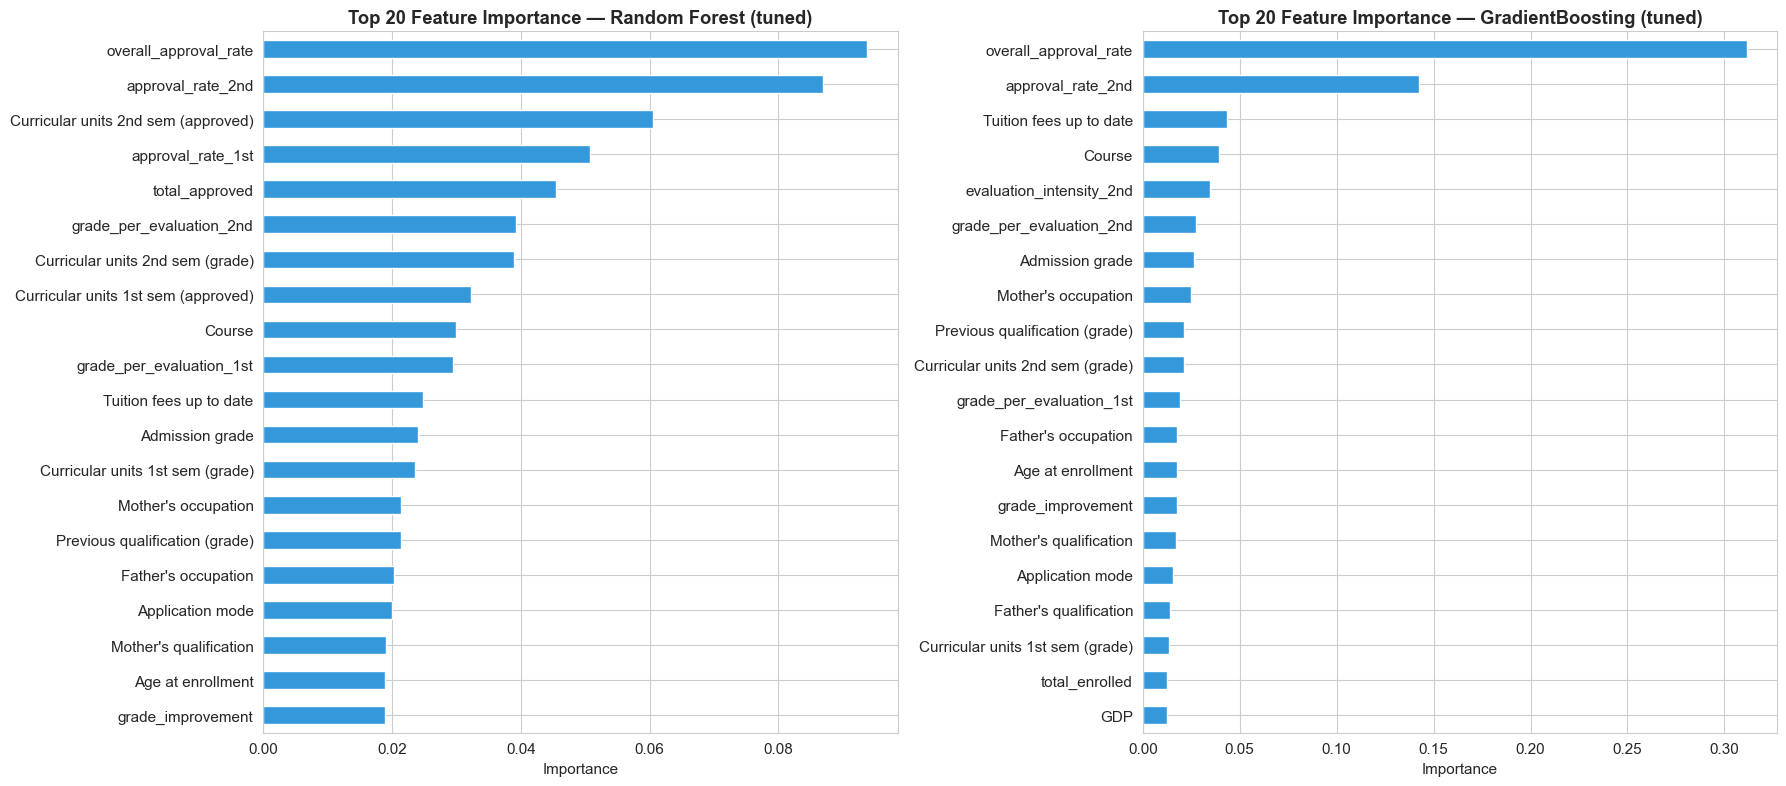

In [7]:
# 特征重要性对比 / Feature importance comparison
feature_names = X_train.columns.tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, (name, model) in zip(axes, [("Random Forest (tuned)", rf_best), (f"{gb_name} (tuned)", gb_best)]):
    importances = pd.Series(model.feature_importances_, index=feature_names).nlargest(20)
    importances.sort_values().plot.barh(ax=ax, color="#3498db", edgecolor="white")
    ax.set_title(f"Top 20 Feature Importance — {name}", fontweight="bold")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "06_feature_importance.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/06_feature_importance.png")
plt.show()

## 5. 全模型综合对比 (Comprehensive Model Comparison)

将 Task 4 的基础模型与本 Notebook 的集成模型进行全面对比，展示 ensemble + tuning 的提升效果。
Compare Task 4 baseline models with ensemble models from this notebook, showing improvements from ensemble + tuning.

In [8]:
# 重新训练基础模型作为对比 / Retrain baseline models for comparison
baseline_models = {
    "Decision Tree": train_model(X_train.values, y_train.values, "dt", max_depth=10),
    "Logistic Regression": train_model(X_train.values, y_train.values, "lr", max_iter=1000),
    "SVM (RBF)": train_model(X_train.values, y_train.values, "svm", kernel="rbf", C=1.0),
}

# 收集所有模型的测试集指标 / Collect test metrics for all models
all_metrics = {}
for name, model in baseline_models.items():
    y_pred = model.predict(X_test.values)
    all_metrics[name] = calculate_metrics(y_test.values, y_pred)

all_metrics["RF (default)"] = metrics_rf
all_metrics[f"{gb_name} (default)"] = metrics_gb
all_metrics["RF (tuned)"] = metrics_rf_best
all_metrics[f"{gb_name} (tuned)"] = metrics_gb_best

# 综合对比表 / Comprehensive comparison table
comparison_df = metrics_comparison_table(all_metrics)
print("全模型对比表 / Full Model Comparison:")
print(comparison_df[["Model", "accuracy", "f1_macro", "f1_weighted"]].round(4).to_string(index=False))

# 保存对比表 / Save comparison
comparison_df.to_csv(os.path.join(project_root, "data", "model_comparison_all.csv"), index=False)

E:\Project\2011machine_learning\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


全模型对比表 / Full Model Comparison:
                     Model  accuracy  f1_macro  f1_weighted
             Decision Tree    0.7107    0.6211       0.6997
       Logistic Regression    0.7684    0.6954       0.7583
                 SVM (RBF)    0.6927    0.5015       0.6213
              RF (default)    0.7751    0.7082       0.7664
GradientBoosting (default)    0.7638    0.6982       0.7572
                RF (tuned)    0.7797    0.7050       0.7675
  GradientBoosting (tuned)    0.7616    0.6910       0.7541


图片已保存 / Plot saved to data/plots/06_all_models_comparison.png


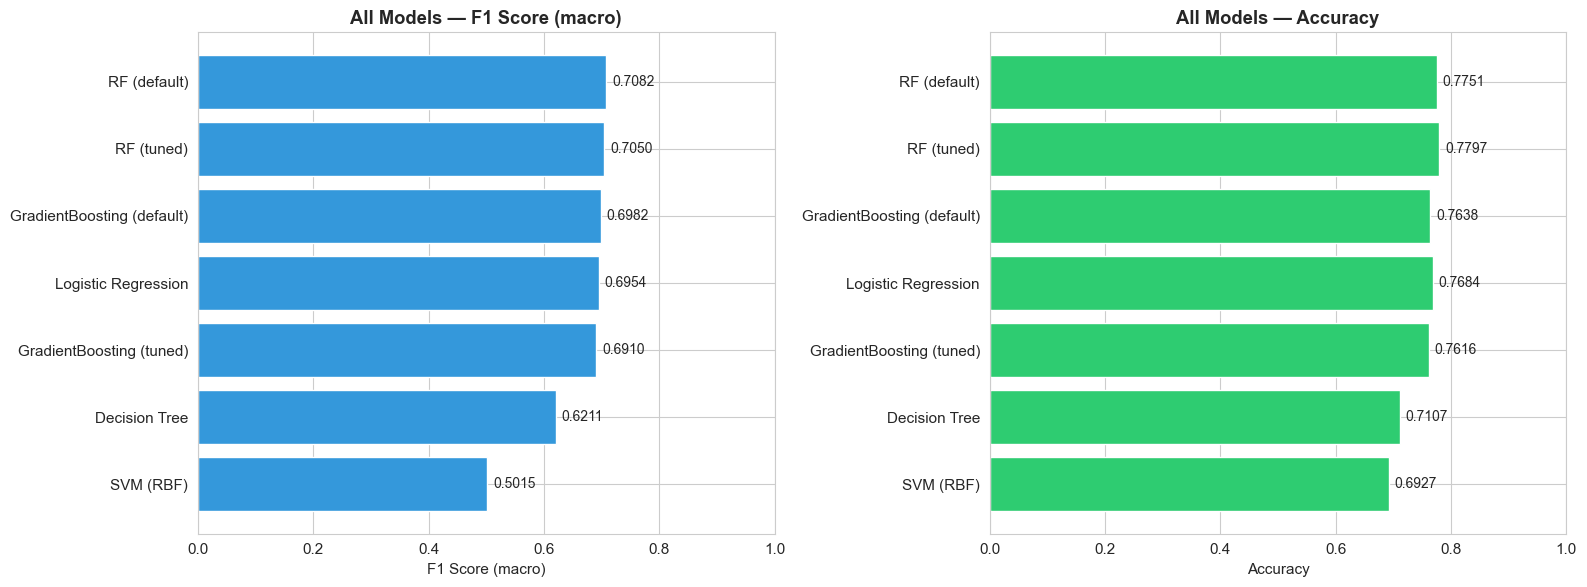

In [9]:
# 可视化全模型对比 / Visualize full comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models_order = comparison_df.sort_values("f1_macro", ascending=True)

# F1 (macro) 对比 / F1 (macro) comparison
axes[0].barh(models_order["Model"], models_order["f1_macro"], color="#3498db", edgecolor="white")
axes[0].set_xlabel("F1 Score (macro)")
axes[0].set_title("All Models — F1 Score (macro)", fontweight="bold")
axes[0].set_xlim(0, 1)
for i, v in enumerate(models_order["f1_macro"]):
    axes[0].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=10)

# Accuracy 对比 / Accuracy comparison
axes[1].barh(models_order["Model"], models_order["accuracy"], color="#2ecc71", edgecolor="white")
axes[1].set_xlabel("Accuracy")
axes[1].set_title("All Models — Accuracy", fontweight="bold")
axes[1].set_xlim(0, 1)
for i, v in enumerate(models_order["accuracy"]):
    axes[1].text(v + 0.01, i, f"{v:.4f}", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "06_all_models_comparison.png"), dpi=150, bbox_inches="tight")
print(f"图片已保存 / Plot saved to data/plots/06_all_models_comparison.png")
plt.show()

Plot saved to E:\Project\2011machine_learning\data\plots\06_roc_ensemble.png


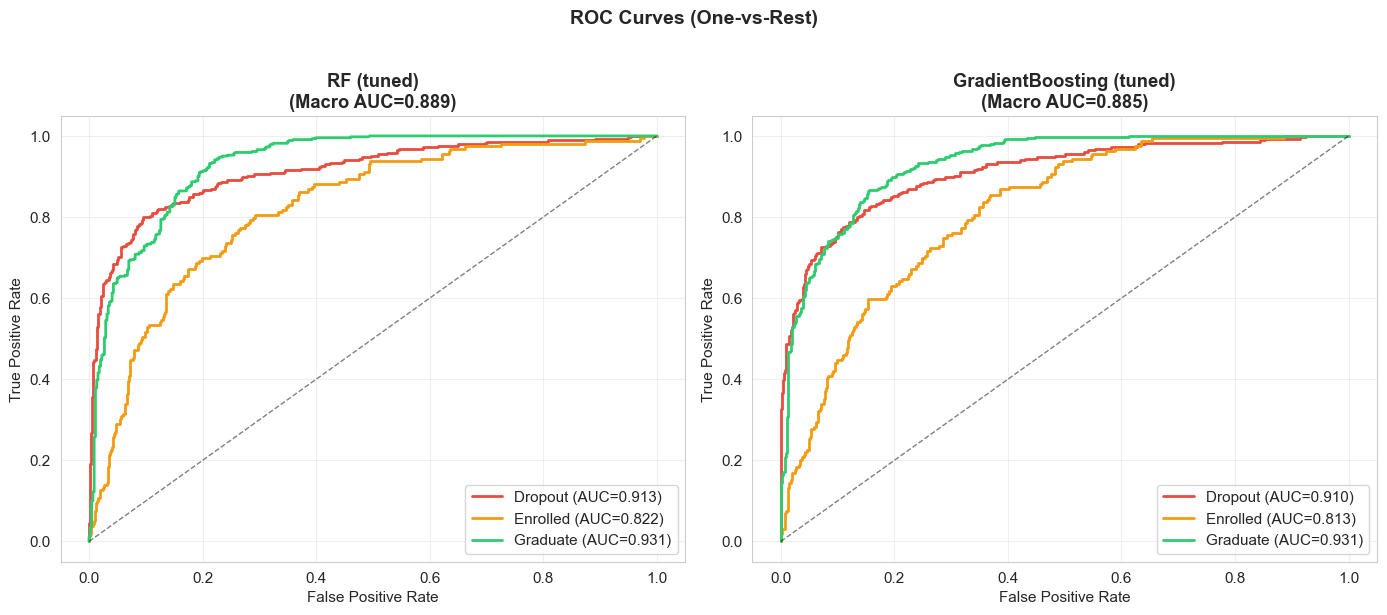

In [10]:
# 绘制集成模型的 ROC 曲线 / Plot ROC curves for ensemble models
ensemble_models = {
    "RF (tuned)": rf_best,
    f"{gb_name} (tuned)": gb_best,
}
fig = plot_roc_curves(
    ensemble_models, X_test.values, y_test.values,
    save_path=os.path.join(PLOT_DIR, "06_roc_ensemble.png"),
)
plt.show()

## 6. 总结与关键发现 (Summary & Key Findings)

### 集成学习提升效果 / Ensemble Learning Improvements

- Random Forest 和 Gradient Boosting/XGBoost 相比基础模型（DT、LR、SVM）有显著性能提升
- 超参数调优进一步提升了集成模型的表现
- 集成方法在处理类别不平衡问题上表现更稳健

### 特征重要性发现 / Feature Importance Findings

- 学业表现相关特征（approval rate, grade）始终排在前列
- 经济因素（tuition fees, scholarship）也是重要预测因子
- 工程特征（如 overall_approval_rate）比原始特征更具预测力

### 调优效果 / Tuning Effects

- GridSearchCV 有效地找到了更优的超参数组合
- 调优后模型的泛化能力（CV 分数）和测试集性能均有提升